# 12 Figure 1 Dataset Overview

Purpose:
This notebook prepares the dataset-level statistics used for Figure 1C and Figure 1D.

Figure 1C:
- mechanism label counts
- structure class counts
- ion type counts
- distribution of log(P_est)

Figure 1D:
- reporting completeness / data availability
- availability of Voc, Jsc, internal resistance, structure, ion/electrolyte, mechanism label, and reported power density

The plots generated here are draft plots for inspection. Final figures will be redrawn in Igor Pro.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Output folder
out_dir = Path("../results/figure1_dataset_overview")
out_dir.mkdir(parents=True, exist_ok=True)

print("Output folder:", out_dir.resolve())

Output folder: <REPOSITORY_ROOT>\results\figure1_dataset_overview


In [6]:
data_path = Path("hydrovoltaic_dataset_phase2_input_utf8.csv")

df = pd.read_csv(data_path, encoding="utf-8-sig")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (159, 52)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,auxiliary_redox_present,continuous_output,water_interaction_mode,rh_percent,inorganic_electrolyte_present,inorganic_electrolyte_type,inorganic_electrolyte_concentration_wt%,polyelectrolyte_present,active_material_raw,material_class,structure_class,ionic_groups,top_electrode,bottom_electrode,electrode_symmetry,metal_electrode,voc_V,jsc_uA_cm2,power_density_uW_cm2,internal_resistance_Mohm,output_timescale_class,stability_time_min,dominant_mechanism,has_anionic,has_cationic,has_zwitterionic,polyelectrolyte_anionic_raw,polyelectrolyte_cationic_raw,polyelectrolyte_zwitterionic_raw,has_any_polyelectrolyte,estimated_power_density_uW_cm2,log_estimated_power_density,ion_type,asym_env,asym_chem,asym_electrode,mechanism_simple,ion_from_material,ion_from_electrolyte,ion_from_water,log_internal_resistance_Mohm,has_internal_resistance
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,60.0,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,1.00,0.0150,0.0053,8.0,days,11520.0,streaming,0,0,0,NaN,NaN,NaN,0,0.003750,-2.425853,proton,1,0,0,streaming,1,0,0,0.903090,1
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,0,1,evaporation_driven,62.0,0,NaN,NaN,0,ZnO,metal oxide,porous,hydroxyl,Al,Al,1,1.0,0.40,0.0200,0.0020,34.3,hours,120.0,streaming,0,0,0,NaN,NaN,NaN,0,0.002000,-2.698753,anion,1,0,0,streaming,0,0,1,1.535294,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,lanthanum iron perovskite oxide,semiconductor,porous,hydroxyl,CNT,CNT,1,0.0,1.50,0.0250,0.0094,60.0,days,12000.0,streaming,0,0,0,NaN,NaN,NaN,0,0.009375,-2.027982,anion,1,1,0,streaming,0,0,1,1.778151,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,0.85,0.0368,NaN,NaN,hours,720.0,streaming,0,0,0,NaN,NaN,NaN,0,0.007820,-2.106738,proton,1,0,0,streaming,1,0,0,NaN,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,55.0,0,NaN,NaN,0,carbonized rice husk,carbon,porous,"carboxyl, hydroxyl, silanol",CNT,CNT,1,0.0,0.16,0.0400,NaN,NaN,hours,600.0,streaming,0,0,0,NaN,NaN,NaN,0,0.001600,-2.795609,proton,1,0,0,streaming,1,0,0,NaN,0


In [3]:
# Load dataset
# Change this filename if your final phase-2 input file has a slightly different name
data_path = Path("hydrovoltaic_dataset_phase2_input_utf8.csv")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (159, 52)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,auxiliary_redox_present,continuous_output,water_interaction_mode,rh_percent,inorganic_electrolyte_present,inorganic_electrolyte_type,inorganic_electrolyte_concentration_wt%,polyelectrolyte_present,active_material_raw,material_class,structure_class,ionic_groups,top_electrode,bottom_electrode,electrode_symmetry,metal_electrode,voc_V,jsc_uA_cm2,power_density_uW_cm2,internal_resistance_Mohm,output_timescale_class,stability_time_min,dominant_mechanism,has_anionic,has_cationic,has_zwitterionic,polyelectrolyte_anionic_raw,polyelectrolyte_cationic_raw,polyelectrolyte_zwitterionic_raw,has_any_polyelectrolyte,estimated_power_density_uW_cm2,log_estimated_power_density,ion_type,asym_env,asym_chem,asym_electrode,mechanism_simple,ion_from_material,ion_from_electrolyte,ion_from_water,log_internal_resistance_Mohm,has_internal_resistance
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,60.0,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,1.00,0.0150,0.0053,8.0,days,11520.0,streaming,0,0,0,NaN,NaN,NaN,0,0.003750,-2.425853,proton,1,0,0,streaming,1,0,0,0.903090,1
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,0,1,evaporation_driven,62.0,0,NaN,NaN,0,ZnO,metal oxide,porous,hydroxyl,Al,Al,1,1.0,0.40,0.0200,0.0020,34.3,hours,120.0,streaming,0,0,0,NaN,NaN,NaN,0,0.002000,-2.698753,anion,1,0,0,streaming,0,0,1,1.535294,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,lanthanum iron perovskite oxide,semiconductor,porous,hydroxyl,CNT,CNT,1,0.0,1.50,0.0250,0.0094,60.0,days,12000.0,streaming,0,0,0,NaN,NaN,NaN,0,0.009375,-2.027982,anion,1,1,0,streaming,0,0,1,1.778151,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,0.85,0.0368,NaN,NaN,hours,720.0,streaming,0,0,0,NaN,NaN,NaN,0,0.007820,-2.106738,proton,1,0,0,streaming,1,0,0,NaN,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,55.0,0,NaN,NaN,0,carbonized rice husk,carbon,porous,"carboxyl, hydroxyl, silanol",CNT,CNT,1,0.0,0.16,0.0400,NaN,NaN,hours,600.0,streaming,0,0,0,NaN,NaN,NaN,0,0.001600,-2.795609,proton,1,0,0,streaming,1,0,0,NaN,0


In [7]:
print("Columns:")
for c in df.columns:
    print(c)

Columns:
paper_doi
review_covered
ref_year
device_structure
built_in_asymmetry
asymmetry_origin
primary_mobile_ion
secondary_ion_present
secondary_mobile_ion
ion_origin
auxiliary_redox_present
continuous_output
water_interaction_mode
rh_percent
inorganic_electrolyte_present
inorganic_electrolyte_type
inorganic_electrolyte_concentration_wt%
polyelectrolyte_present
active_material_raw
material_class
structure_class
ionic_groups
top_electrode
bottom_electrode
electrode_symmetry
metal_electrode
voc_V
jsc_uA_cm2
power_density_uW_cm2
internal_resistance_Mohm
output_timescale_class
stability_time_min
dominant_mechanism
has_anionic
has_cationic
has_zwitterionic
polyelectrolyte_anionic_raw
polyelectrolyte_cationic_raw
polyelectrolyte_zwitterionic_raw
has_any_polyelectrolyte
estimated_power_density_uW_cm2
log_estimated_power_density
ion_type
asym_env
asym_chem
asym_electrode
mechanism_simple
ion_from_material
ion_from_electrolyte
ion_from_water
log_internal_resistance_Mohm
has_internal_resistanc

In [8]:
key_cols = [
    "mechanism_simple",
    "structure_class",
    "ion_type",
    "log_estimated_power_density",
    "estimated_power_density_uW_cm2",
    "voc_V",
    "jsc_uA_cm2",
    "power_density_uW_cm2",
    "log_internal_resistance_Mohm",
    "internal_resistance_Mohm",
    "has_internal_resistance",
    "inorganic_electrolyte_present",
    "inorganic_electrolyte_type"
]

for col in key_cols:
    print(f"{col:35s}", col in df.columns)

mechanism_simple                    True
structure_class                     True
ion_type                            True
log_estimated_power_density         True
estimated_power_density_uW_cm2      True
voc_V                               True
jsc_uA_cm2                          True
power_density_uW_cm2                True
log_internal_resistance_Mohm        True
internal_resistance_Mohm            True
has_internal_resistance             True
inorganic_electrolyte_present       True
inorganic_electrolyte_type          True


## Part A — Figure 1C 数据

In [9]:
# Count tables for mechanism / structure / ion
def count_table(df, col, label_name):
    """
    Create a count and percentage table for a categorical variable.
    """
    tmp = (
        df[col]
        .fillna("missing")
        .astype(str)
        .replace({"": "missing", "nan": "missing", "None": "missing"})
        .value_counts()
        .reset_index()
    )
    tmp.columns = [label_name, "count"]
    tmp["percent"] = tmp["count"] / tmp["count"].sum() * 100
    return tmp

mechanism_counts = count_table(df, "mechanism_simple", "mechanism_simple")
structure_counts = count_table(df, "structure_class", "structure_class")
ion_counts = count_table(df, "ion_type", "ion_type")

print("Mechanism counts")
display(mechanism_counts)

print("Structure counts")
display(structure_counts)

print("Ion type counts")
display(ion_counts)

Mechanism counts


,mechanism_simple,count,percent
0,ion_gradient,107,67.295597
1,streaming,52,32.704403


Structure counts


,structure_class,count,percent
0,porous,118,74.213836
1,film,22,13.836478
2,hydrogel,14,8.805031
3,hydrogel + porous,4,2.515723
4,hydrogel + film,1,0.628931


Ion type counts


,ion_type,count,percent
0,proton,96,60.377358
1,other_cation,54,33.962264
2,anion,9,5.660377


In [10]:
# Target distribution data
target_col = "log_estimated_power_density"

target_df = df[[target_col]].dropna().copy()
target_df = target_df.rename(columns={target_col: "log_P_est"})

print("Target count:", len(target_df))
display(target_df.describe())

Target count: 159


,log_P_est
count,159.000000
mean,-0.380143
std,1.324738
min,-4.283997
25%,-1.243577
50%,-0.281913
75%,0.559267
max,2.916454


In [11]:
# Histogram bin data for Igor 这个不是必须，但给 Igor 很方便。
# Histogram data for log(P_est)
hist_counts, bin_edges = np.histogram(target_df["log_P_est"], bins=15)

hist_df = pd.DataFrame({
    "bin_left": bin_edges[:-1],
    "bin_right": bin_edges[1:],
    "bin_center": (bin_edges[:-1] + bin_edges[1:]) / 2,
    "count": hist_counts
})

display(hist_df)


,bin_left,bin_right,bin_center,count
0,-4.283997,-3.803967,-4.043982,1
1,-3.803967,-3.323937,-3.563952,1
2,-3.323937,-2.843907,-3.083922,4
3,-2.843907,-2.363876,-2.603892,5
4,-2.363876,-1.883846,-2.123861,11
5,-1.883846,-1.403816,-1.643831,11
6,-1.403816,-0.923786,-1.163801,26
7,-0.923786,-0.443756,-0.683771,14
8,-0.443756,0.036274,-0.203741,19
9,0.036274,0.516304,0.276289,26


In [12]:
# Export Figure 1C CSV files
mechanism_counts.to_csv(out_dir / "fig1C_mechanism_counts.csv", index=False, encoding="utf-8-sig")
structure_counts.to_csv(out_dir / "fig1C_structure_counts.csv", index=False, encoding="utf-8-sig")
ion_counts.to_csv(out_dir / "fig1C_ion_type_counts.csv", index=False, encoding="utf-8-sig")
target_df.to_csv(out_dir / "fig1C_log_P_est_raw.csv", index=False, encoding="utf-8-sig")
hist_df.to_csv(out_dir / "fig1C_log_P_est_histogram_bins.csv", index=False, encoding="utf-8-sig")

print("Figure 1C CSV files exported to:")
print(out_dir.resolve())

Figure 1C CSV files exported to:
<REPOSITORY_ROOT>\results\figure1_dataset_overview


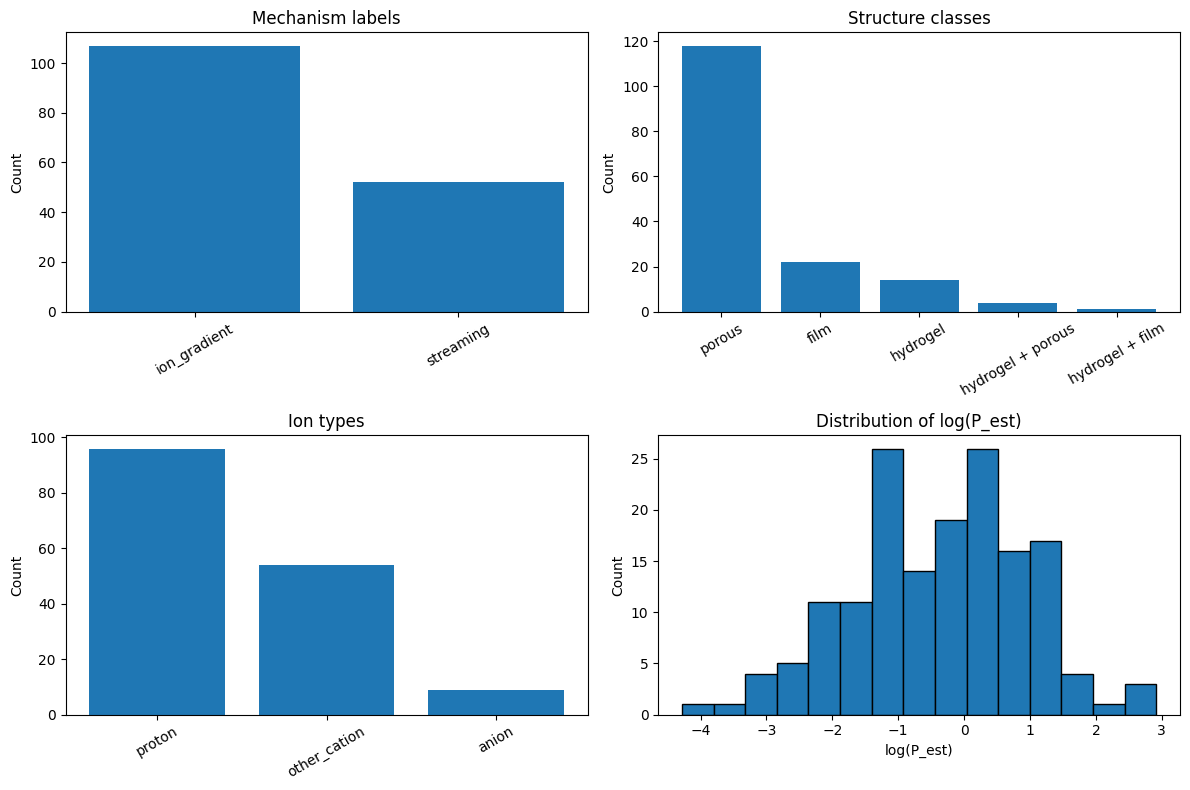

In [13]:
# Draft plot for Figure 1C

# 这个只是 notebook 里检查用，最后你用 Igor 重画。
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Mechanism counts
axes[0, 0].bar(mechanism_counts["mechanism_simple"], mechanism_counts["count"])
axes[0, 0].set_title("Mechanism labels")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=30)

# Structure counts
axes[0, 1].bar(structure_counts["structure_class"], structure_counts["count"])
axes[0, 1].set_title("Structure classes")
axes[0, 1].set_ylabel("Count")
axes[0, 1].tick_params(axis="x", rotation=30)

# Ion type counts
axes[1, 0].bar(ion_counts["ion_type"], ion_counts["count"])
axes[1, 0].set_title("Ion types")
axes[1, 0].set_ylabel("Count")
axes[1, 0].tick_params(axis="x", rotation=30)

# Target distribution
axes[1, 1].hist(target_df["log_P_est"], bins=15, edgecolor="black")
axes[1, 1].set_title("Distribution of log(P_est)")
axes[1, 1].set_xlabel("log(P_est)")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## Part B — Figure 1D 数据

In [14]:
# Define availability function
def is_available(series):
    """
    Define availability for literature-extracted values.
    Treat NaN, empty strings, and common missing labels as unavailable.
    Numeric zero is treated as available, because zero may be a valid encoded value.
    """
    s = series.copy()
    
    if s.dtype == "O":
        s = s.astype(str).str.strip()
        missing_like = ["", "nan", "none", "None", "NaN", "NA", "N/A", "not reported", "missing", "-"]
        return ~s.isin(missing_like)
    else:
        return s.notna()

In [15]:
# Choose variables for reporting completeness

# 这里我用你现在数据里的实际列名。internal resistance 有时列名会变，所以写得稳一点。
# Identify internal resistance column
possible_R_cols = [
    "internal_resistance_Mohm",
    "internal_resistance_MΩ",
    "log_internal_resistance_Mohm",
    "has_internal_resistance"
]

R_col = None
for c in possible_R_cols:
    if c in df.columns:
        R_col = c
        break

print("Internal resistance column used:", R_col)

Internal resistance column used: internal_resistance_Mohm


In [16]:
# 然后定义 Figure 1D 的变量：
availability_items = {
    "Voc": ["voc_V"],
    "Jsc": ["jsc_uA_cm2"],
    "Reported power density": ["power_density_uW_cm2"],
    "Internal resistance": [R_col] if R_col is not None else [],
    "Structure": ["structure_class"],
    "Ion type": ["ion_type"],
    "Electrolyte descriptor": ["inorganic_electrolyte_present", "inorganic_electrolyte_type"],
    "Mechanism label": ["mechanism_simple"]
}

In [17]:
# Compute availability table
availability_rows = []

n_total = len(df)

for item, cols in availability_items.items():
    cols = [c for c in cols if c in df.columns]
    
    if len(cols) == 0:
        n_available = 0
        note = "column not found"
    elif len(cols) == 1:
        mask = is_available(df[cols[0]])
        n_available = mask.sum()
        note = cols[0]
    else:
        # available if any of the related columns is available
        masks = [is_available(df[c]) for c in cols]
        combined_mask = np.logical_or.reduce(masks)
        n_available = combined_mask.sum()
        note = " OR ".join(cols)
    
    availability_rows.append({
        "variable_group": item,
        "columns_used": note,
        "n_available": int(n_available),
        "n_total": int(n_total),
        "availability_percent": n_available / n_total * 100
    })

availability_df = pd.DataFrame(availability_rows)

display(availability_df)

,variable_group,columns_used,n_available,n_total,availability_percent
0,Voc,voc_V,159,159,100.000000
1,Jsc,jsc_uA_cm2,159,159,100.000000
2,Reported power density,power_density_uW_cm2,108,159,67.924528
3,Internal resistance,internal_resistance_Mohm,112,159,70.440252
4,Structure,structure_class,159,159,100.000000
5,Ion type,ion_type,159,159,100.000000
6,Electrolyte descriptor,inorganic_electrolyte_present OR inorganic_ele...,159,159,100.000000
7,Mechanism label,mechanism_simple,159,159,100.000000


In [18]:
# Export Figure 1D CSV
availability_df.to_csv(
    out_dir / "fig1D_reporting_completeness.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Figure 1D availability table exported:")
print(out_dir / "fig1D_reporting_completeness.csv")

Figure 1D availability table exported:
..\results\figure1_dataset_overview\fig1D_reporting_completeness.csv


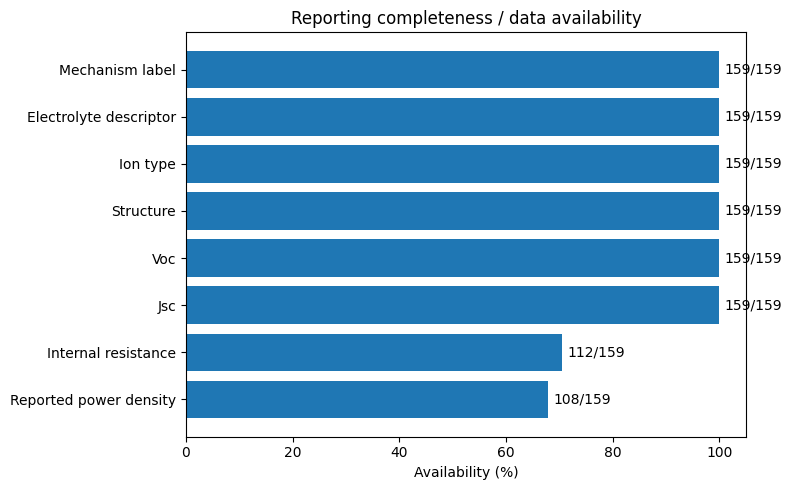

In [19]:
# Draft plot for Figure 1D
availability_plot_df = availability_df.sort_values("availability_percent", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(
    availability_plot_df["variable_group"],
    availability_plot_df["availability_percent"]
)

plt.xlabel("Availability (%)")
plt.title("Reporting completeness / data availability")
plt.xlim(0, 105)

for i, row in enumerate(availability_plot_df.itertuples()):
    plt.text(
        row.availability_percent + 1,
        i,
        f"{row.n_available}/{row.n_total}",
        va="center"
    )

plt.tight_layout()
plt.show()

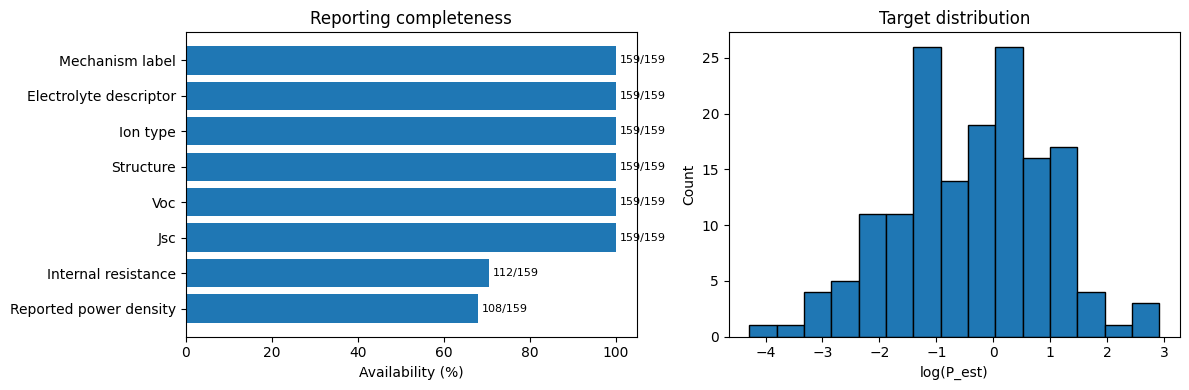

In [20]:
# Optional combined draft for Figure 1D

# 如果你想把 availability + log(P_est) distribution 放在一个 panel 里检查：
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Availability
plot_df = availability_df.sort_values("availability_percent", ascending=True)
axes[0].barh(plot_df["variable_group"], plot_df["availability_percent"])
axes[0].set_xlabel("Availability (%)")
axes[0].set_title("Reporting completeness")
axes[0].set_xlim(0, 105)

for i, row in enumerate(plot_df.itertuples()):
    axes[0].text(
        row.availability_percent + 1,
        i,
        f"{row.n_available}/{row.n_total}",
        va="center",
        fontsize=8
    )

# Target distribution
axes[1].hist(target_df["log_P_est"], bins=15, edgecolor="black")
axes[1].set_xlabel("log(P_est)")
axes[1].set_ylabel("Count")
axes[1].set_title("Target distribution")

plt.tight_layout()
plt.show()

## Summary for Figure 1C and Figure 1D

Figure 1C summarizes the composition of the curated hydrovoltaic dataset, including mechanism labels, structure classes, ion types, and the distribution of the log-transformed estimated power-density target.

Figure 1D summarizes reporting completeness for key literature-extracted variables. The availability plot highlights the heterogeneity of hydrovoltaic reporting and supports the need for standardized target construction and descriptor-based analysis.

All CSV files for Igor Pro redrawing were exported to:
`../results/figure1_dataset_overview/`

# Final Figure 1 production

This section generates the final production plots for:
- Fig. 1C: dataset composition and target distribution
- Fig. 1D: reporting completeness

The original analysis and draft plotting cells above are kept unchanged.
Final multi-panel assembly is performed in Adobe Illustrator.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# =========================
# Output folders
# =========================
fig1_dir = Path("../results/figure1_dataset_overview")
final_dir = fig1_dir / "final_panels"
final_dir.mkdir(parents=True, exist_ok=True)

print("Figure 1 result folder:", fig1_dir.resolve())
print("Final panel output folder:", final_dir.resolve())


# =========================
# Final style
# =========================
COLORS_FINAL = {
    "black": "#000000",
    "dark_gray": "#4D4D4D",
    "gray": "#8C8C8C",
    "light_gray": "#C7C7C7",
    "very_light_gray": "#EFEFEF",
}

# Descriptor palette (same general family as Figure 2 / 5,
# but used here only as categorical colors, not regime colors)
MECH_COLORS = {
    "ion gradient": "#5B7DB1",   # muted blue
    "streaming": "#A07CB8",      # muted purple
}

ION_COLORS = {
    "proton": "#B08C5A",         # khaki / brown
    "other cation": "#4C9A8A",   # muted teal
    "anion": "#6C8EBF",          # muted blue
}

STRUCTURE_COLORS = {
    "porous": "#B08C5A",
    "film": "#6C8EBF",
    "hydrogel": "#4C9A8A",
    "hydrogel + porous": "#A07CB8",
    "hydrogel + film": "#7F7F7F",
    "missing": "#C7C7C7",
}

AVAILABILITY_COLORS = {
    "performance": "#6C8EBF",
    "descriptor": "#4C9A8A",
}

def set_final_style():
    mpl.rcParams.update({
        "font.family": "Arial",
        "font.size": 8.5,
        "font.weight": "normal",

        "mathtext.fontset": "custom",
        "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic",
        "mathtext.bf": "Arial:bold",

        "axes.linewidth": 1.0,
        "axes.labelsize": 9.5,
        "axes.titlesize": 10,
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "xtick.labelsize": 8.0,
        "ytick.labelsize": 8.0,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,

        "lines.linewidth": 1.2,
        "lines.markersize": 4,

        "legend.fontsize": 7.8,
        "legend.frameon": False,

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        "savefig.dpi": 600,
        "figure.dpi": 150,
        "axes.grid": False,
    })


def format_final_ax(ax, mirror=True):
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color(COLORS_FINAL["black"])

    ax.spines["top"].set_visible(mirror)
    ax.spines["right"].set_visible(mirror)

    ax.tick_params(
        direction="out",
        width=1.0,
        length=4,
        color=COLORS_FINAL["black"],
        top=False,
        right=False,
    )

    return ax


def save_final_panel(fig, name):
    pdf_path = final_dir / f"{name}.pdf"
    svg_path = final_dir / f"{name}.svg"
    png_path = final_dir / f"{name}.png"

    fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.03)
    fig.savefig(svg_path, bbox_inches="tight", pad_inches=0.03)
    fig.savefig(png_path, dpi=600, bbox_inches="tight", pad_inches=0.03)

    print("Saved:")
    print(" -", pdf_path.name)
    print(" -", svg_path.name)
    print(" -", png_path.name)


set_final_style()


# =========================
# Load exported Figure 1 data
# =========================
fig1C_mech_path = fig1_dir / "fig1C_mechanism_counts.csv"
fig1C_struct_path = fig1_dir / "fig1C_structure_counts.csv"
fig1C_ion_path = fig1_dir / "fig1C_ion_type_counts.csv"
fig1C_hist_path = fig1_dir / "fig1C_log_P_est_histogram_bins.csv"
fig1D_path = fig1_dir / "fig1D_reporting_completeness.csv"

required_paths = [
    fig1C_mech_path,
    fig1C_struct_path,
    fig1C_ion_path,
    fig1C_hist_path,
    fig1D_path,
]

for p in required_paths:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

mech_df = pd.read_csv(fig1C_mech_path, encoding="utf-8-sig")
struct_df = pd.read_csv(fig1C_struct_path, encoding="utf-8-sig")
ion_df = pd.read_csv(fig1C_ion_path, encoding="utf-8-sig")
hist_df = pd.read_csv(fig1C_hist_path, encoding="utf-8-sig")
avail_df = pd.read_csv(fig1D_path, encoding="utf-8-sig")

print("Loaded Figure 1 data:")
print(" -", fig1C_mech_path.name, mech_df.shape)
print(" -", fig1C_struct_path.name, struct_df.shape)
print(" -", fig1C_ion_path.name, ion_df.shape)
print(" -", fig1C_hist_path.name, hist_df.shape)
print(" -", fig1D_path.name, avail_df.shape)

display(mech_df)
display(struct_df)
display(ion_df)
display(hist_df.head())
display(avail_df)

Figure 1 result folder: <REPOSITORY_ROOT>\results\figure1_dataset_overview
Final panel output folder: <REPOSITORY_ROOT>\results\figure1_dataset_overview\final_panels
Loaded Figure 1 data:
 - fig1C_mechanism_counts.csv (2, 3)
 - fig1C_structure_counts.csv (5, 3)
 - fig1C_ion_type_counts.csv (3, 3)
 - fig1C_log_P_est_histogram_bins.csv (15, 4)
 - fig1D_reporting_completeness.csv (8, 5)


,mechanism_simple,count,percent
0,ion_gradient,107,67.295597
1,streaming,52,32.704403


,structure_class,count,percent
0,porous,118,74.213836
1,film,22,13.836478
2,hydrogel,14,8.805031
3,hydrogel + porous,4,2.515723
4,hydrogel + film,1,0.628931


,ion_type,count,percent
0,proton,96,60.377358
1,other_cation,54,33.962264
2,anion,9,5.660377


,bin_left,bin_right,bin_center,count
0,-4.283997,-3.803967,-4.043982,1
1,-3.803967,-3.323937,-3.563952,1
2,-3.323937,-2.843907,-3.083922,4
3,-2.843907,-2.363876,-2.603892,5
4,-2.363876,-1.883846,-2.123861,11


,variable_group,columns_used,n_available,n_total,availability_percent
0,Voc,voc_V,159,159,100.000000
1,Jsc,jsc_uA_cm2,159,159,100.000000
2,Reported power density,power_density_uW_cm2,108,159,67.924528
3,Internal resistance,internal_resistance_Mohm,112,159,70.440252
4,Structure,structure_class,159,159,100.000000
5,Ion type,ion_type,159,159,100.000000
6,Electrolyte descriptor,inorganic_electrolyte_present OR inorganic_ele...,159,159,100.000000
7,Mechanism label,mechanism_simple,159,159,100.000000


In [2]:
def normalize_token(x):
    s = str(x).strip().lower()
    s = s.replace("_", " ")
    s = " ".join(s.split())
    return s


def prep_count_df(df, raw_col, order, label_map):
    tmp = df.copy()
    tmp[raw_col] = tmp[raw_col].map(normalize_token)

    # keep only known categories in desired order
    tmp = tmp.set_index(raw_col).reindex(order).reset_index()

    # fill missing count rows if needed
    if "count" in tmp.columns:
        tmp["count"] = tmp["count"].fillna(0).astype(int)
    if "percent" in tmp.columns:
        tmp["percent"] = tmp["percent"].fillna(0.0)

    tmp["plot_label"] = tmp[raw_col].map(label_map)
    return tmp


def barh_count_panel(ax, df, cat_col, title, color_map, xlabel="Count"):
    y = np.arange(len(df))
    colors = [color_map.get(v, COLORS_FINAL["light_gray"]) for v in df[cat_col]]

    ax.barh(
        y,
        df["count"],
        color=colors,
        edgecolor=COLORS_FINAL["black"],
        linewidth=0.8,
        zorder=2,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(df["plot_label"])
    ax.set_xlabel(xlabel)
    ax.set_title(title)

    xmax = max(df["count"].max() * 1.22, 5)
    ax.set_xlim(0, xmax)

    for i, row in enumerate(df.itertuples()):
        ax.text(
            row.count + 0.3,
            i,
            f"{row.count} ({row.percent:.0f}%)",
            va="center",
            ha="left",
            fontsize=7.2,
            color=COLORS_FINAL["dark_gray"],
        )

    format_final_ax(ax, mirror=True)
    return ax

Saved:
 - fig1C_final_dataset_composition_and_target_distribution.pdf
 - fig1C_final_dataset_composition_and_target_distribution.svg
 - fig1C_final_dataset_composition_and_target_distribution.png


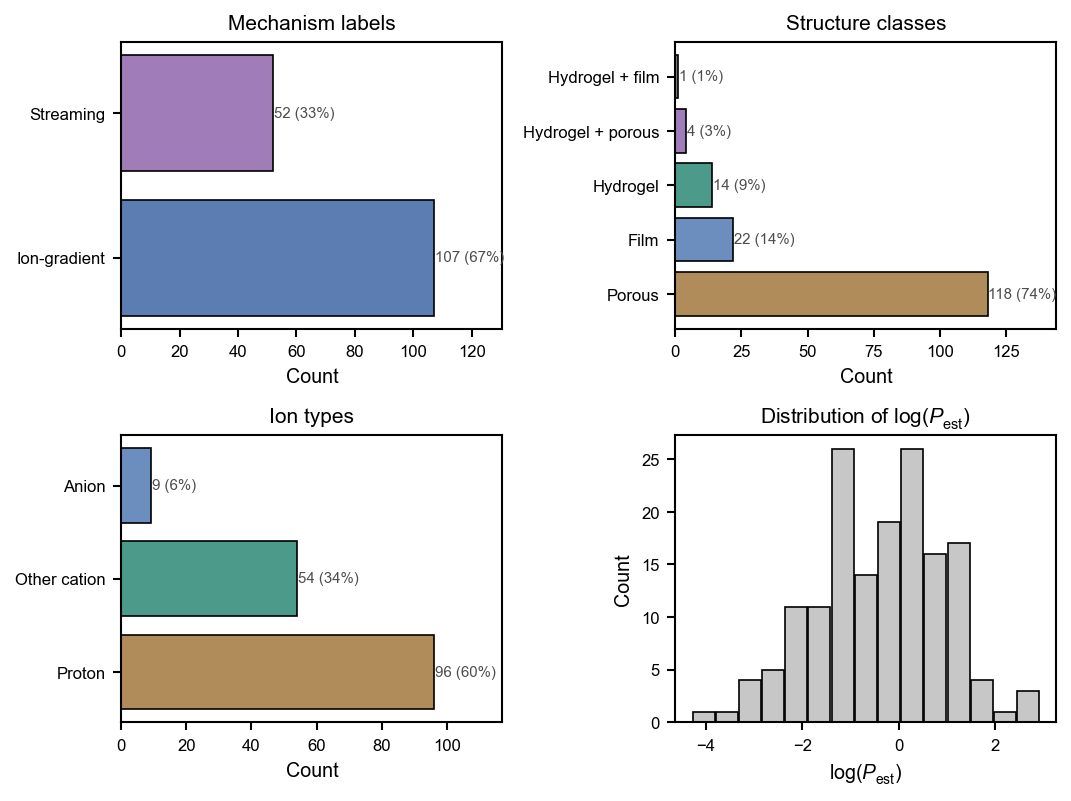

In [3]:
# =========================
# Final Fig. 1C
# Dataset composition + target distribution
# =========================

set_final_style()

# ---------- desired category order ----------
mech_order = ["ion gradient", "streaming"]
mech_labels = {
    "ion gradient": "Ion-gradient",
    "streaming": "Streaming",
}

struct_order = [
    "porous",
    "film",
    "hydrogel",
    "hydrogel + porous",
    "hydrogel + film",
]
struct_labels = {
    "porous": "Porous",
    "film": "Film",
    "hydrogel": "Hydrogel",
    "hydrogel + porous": "Hydrogel + porous",
    "hydrogel + film": "Hydrogel + film",
}

ion_order = ["proton", "other cation", "anion"]
ion_labels = {
    "proton": "Proton",
    "other cation": "Other cation",
    "anion": "Anion",
}

mech_plot = prep_count_df(mech_df, "mechanism_simple", mech_order, mech_labels)
struct_plot = prep_count_df(struct_df, "structure_class", struct_order, struct_labels)
ion_plot = prep_count_df(ion_df, "ion_type", ion_order, ion_labels)

# ---------- combined panel ----------
fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.4))

# 1C-1 mechanism
barh_count_panel(
    axes[0, 0],
    mech_plot,
    "mechanism_simple",
    "Mechanism labels",
    MECH_COLORS,
    xlabel="Count",
)

# 1C-2 structure
barh_count_panel(
    axes[0, 1],
    struct_plot,
    "structure_class",
    "Structure classes",
    STRUCTURE_COLORS,
    xlabel="Count",
)

# 1C-3 ion type
barh_count_panel(
    axes[1, 0],
    ion_plot,
    "ion_type",
    "Ion types",
    ION_COLORS,
    xlabel="Count",
)

# 1C-4 histogram of log(P_est)
ax = axes[1, 1]

bar_width = hist_df["bin_right"] - hist_df["bin_left"]

ax.bar(
    hist_df["bin_center"],
    hist_df["count"],
    width=bar_width * 0.95,
    color=COLORS_FINAL["light_gray"],
    edgecolor=COLORS_FINAL["black"],
    linewidth=0.8,
    zorder=2,
)

ax.set_title(r"Distribution of $\log(P_{\mathrm{est}})$")
ax.set_xlabel(r"$\log(P_{\mathrm{est}})$")
ax.set_ylabel("Count")

format_final_ax(ax, mirror=True)

plt.tight_layout()

save_final_panel(fig, "fig1C_final_dataset_composition_and_target_distribution")

plt.show()

Saved:
 - fig1D_final_reporting_completeness.pdf
 - fig1D_final_reporting_completeness.svg
 - fig1D_final_reporting_completeness.png


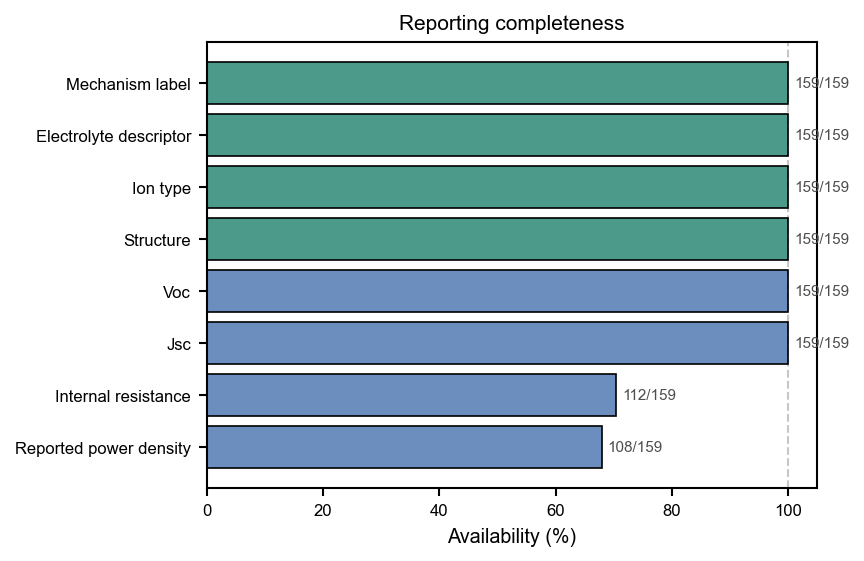

In [4]:
# =========================
# Final Fig. 1D
# Reporting completeness
# =========================

set_final_style()

plot_df = avail_df.copy()

# classify rows into two broad groups
performance_items = {
    "Voc",
    "Jsc",
    "Reported power density",
    "Internal resistance",
}

plot_df["group_type"] = np.where(
    plot_df["variable_group"].isin(performance_items),
    "performance",
    "descriptor"
)

plot_df = plot_df.sort_values("availability_percent", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(5.8, 3.8))

y = np.arange(len(plot_df))
colors = [AVAILABILITY_COLORS[g] for g in plot_df["group_type"]]

ax.barh(
    y,
    plot_df["availability_percent"],
    color=colors,
    edgecolor=COLORS_FINAL["black"],
    linewidth=0.8,
    zorder=2,
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["variable_group"])
ax.set_xlabel("Availability (%)")
ax.set_title("Reporting completeness")
ax.set_xlim(0, 105)

for i, row in enumerate(plot_df.itertuples()):
    ax.text(
        row.availability_percent + 1,
        i,
        f"{row.n_available}/{row.n_total}",
        va="center",
        ha="left",
        fontsize=7.3,
        color=COLORS_FINAL["dark_gray"],
    )

# optional light reference line at 100%
ax.axvline(
    100,
    linestyle="--",
    linewidth=1.0,
    color=COLORS_FINAL["light_gray"],
    zorder=1,
)

format_final_ax(ax, mirror=True)

plt.tight_layout()

save_final_panel(fig, "fig1D_final_reporting_completeness")

plt.show()

In [5]:
print("Final Figure 1 panel files:")

for p in sorted(final_dir.glob("fig1*_final*")):
    print(" -", p.name)

Final Figure 1 panel files:
 - fig1C_final_dataset_composition_and_target_distribution.pdf
 - fig1C_final_dataset_composition_and_target_distribution.png
 - fig1C_final_dataset_composition_and_target_distribution.svg
 - fig1D_final_reporting_completeness.pdf
 - fig1D_final_reporting_completeness.png
 - fig1D_final_reporting_completeness.svg
